In [1]:
from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

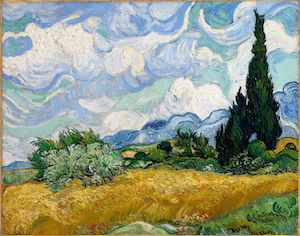

In [2]:
display(REFERENCE_IMAGE)

In [3]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = False
# Enable random search
random_search = False

In [4]:
def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(f"./img/van_gogh_intermediate_{evo.seed}_{evo.mutation_strength_schedule}_{evo.initial_mutation_strength}_{evo.final_mutation_strength}_{evo.mutation_prob_schedule}_{evo.initial_mutation_prob}_{evo.final_mutation_prob}_{time['num-generations']:05d}.png")

def run_algorithm(settings):
    seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob = settings
    start = time()
    
    data = []
    evo = Evolution(100,
                    REFERENCE_IMAGE,
                    population_size=100,
                    generation_reporter=reporter,
                    crossover_method="ONE_POINT",
                    seed=seed,
                    initialization="RANDOM",
                    generation_budget=500,
                    
                    mutation_strength_schedule=mutation_strength_schedule,
                    initial_mutation_strength=initial_strength,
                    final_mutation_strength=final_strength,
                    
                    mutation_prob_schedule=mutation_prob_schedule,
                    initial_mutation_prob=initial_prob,
                    final_mutation_prob=final_prob,
                    
                    selection_name='tournament_4',
                    verbose=verbose_output)
    data = evo.run()
    time_spent = time() - start
    print(f"Done: seed {seed} - strength {mutation_strength_schedule} {initial_strength} -> {final_strength} - prob {mutation_prob_schedule} {initial_prob} -> {final_prob} - in {int(time_spent)} seconds")
    
    return data

## Running a single instance

In [5]:
#%%time
#data = run_algorithm((0, "constant", 0.5, 0.05, "constant", 0.1, 0.01))

## Random Search

In [6]:
%%time

n_trials = 20

data = []
if random_search:
    for seed in range(n_trials):
        mutation_strength_schedule = np.random.choice(["constant", "linear", "exponential", "quadratic"])
        initial_strength = np.random.uniform(0.1, 1.0)
        if mutation_strength_schedule == "constant":
            final_strength = initial_strength
        else:
            final_strength = np.random.uniform(0.001, initial_strength)
    
        mutation_prob_schedule = np.random.choice(["constant", "linear", "exponential", "quadratic"])
        initial_prob = np.random.uniform(0.001, 0.1)
        if mutation_prob_schedule == "constant":
            final_prob = initial_prob
        else:
            final_prob = np.random.uniform(0.0001, initial_prob)
    
        data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

    df = pd.DataFrame(data)
    df["time-elapsed"] = df["time-elapsed"].round(0)

    summary = df.groupby([
        "mutation-strength-schedule",
        "initial-mutation-strength",
        "final-mutation-strength",
        "mutation-prob-schedule",
        "initial-mutation-prob",
        "final-mutation-prob"
    ])["best-fitness"].min().reset_index()
    
    summary.sort_values("best-fitness").head(20)

CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 9.54 μs


## Running a sweep of settings

In [7]:
from vangogh.util import NUM_VARIABLES_PER_POINT

num_points = 100
genotype_length = num_points * NUM_VARIABLES_PER_POINT

prob_baseline = 1 / genotype_length

print(prob_baseline)

0.002


In [8]:
%%time

# baseline
data = []

for seed in range(5):
    data.extend(run_algorithm((seed, "baseline", 0.25, 0.25, "baseline", prob_baseline, prob_baseline)))

Done: seed 0 - strength baseline 0.25 -> 0.25 - prob baseline 0.002 -> 0.002 - in 142 seconds
Done: seed 1 - strength baseline 0.25 -> 0.25 - prob baseline 0.002 -> 0.002 - in 143 seconds
Done: seed 2 - strength baseline 0.25 -> 0.25 - prob baseline 0.002 -> 0.002 - in 144 seconds
Done: seed 3 - strength baseline 0.25 -> 0.25 - prob baseline 0.002 -> 0.002 - in 142 seconds
Done: seed 4 - strength baseline 0.25 -> 0.25 - prob baseline 0.002 -> 0.002 - in 143 seconds
CPU times: user 6min 33s, sys: 56.9 s, total: 7min 29s
Wall time: 11min 55s


In [11]:
%%time

for seed in range(5):
    mutation_strength_schedule = "exponential"
    initial_strength = 0.85
    final_strength = 0.15

    mutation_prob_schedule = "quadratic"
    initial_prob = 0.02
    final_prob = 0.002

    data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

Done: seed 0 - strength exponential 0.85 -> 0.15 - prob quadratic 0.02 -> 0.002 - in 143 seconds
Done: seed 1 - strength exponential 0.85 -> 0.15 - prob quadratic 0.02 -> 0.002 - in 141 seconds
Done: seed 2 - strength exponential 0.85 -> 0.15 - prob quadratic 0.02 -> 0.002 - in 140 seconds
Done: seed 3 - strength exponential 0.85 -> 0.15 - prob quadratic 0.02 -> 0.002 - in 140 seconds
Done: seed 4 - strength exponential 0.85 -> 0.15 - prob quadratic 0.02 -> 0.002 - in 140 seconds
CPU times: user 6min 29s, sys: 58 s, total: 7min 27s
Wall time: 11min 46s


In [12]:
%%time

initial_strength = 0.85
final_strength = 0.15
initial_prob = 0.02
final_prob = 0.002
generation_budget = 500
strength_values = [(initial_strength * (final_strength / initial_strength) ** (generation / (generation_budget - 1))) for generation in range(generation_budget)]
prob_values = [initial_prob + (final_prob - initial_prob) * ((generation / (generation_budget - 1)) ** 2) for generation in range(generation_budget)]

for seed in range(5):
    mutation_strength_schedule = "constant"
    initial_strength = sum(strength_values) / generation_budget
    final_strength = sum(strength_values) / generation_budget

    mutation_prob_schedule = "constant"
    initial_prob = sum(prob_values) / generation_budget
    final_prob = sum(prob_values) / generation_budget

    data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

Done: seed 0 - strength constant 0.40374430901539493 -> 0.40374430901539493 - prob constant 0.013993987975951914 -> 0.013993987975951914 - in 145 seconds
Done: seed 1 - strength constant 0.40374430901539493 -> 0.40374430901539493 - prob constant 0.013993987975951914 -> 0.013993987975951914 - in 140 seconds
Done: seed 2 - strength constant 0.40374430901539493 -> 0.40374430901539493 - prob constant 0.013993987975951914 -> 0.013993987975951914 - in 140 seconds
Done: seed 3 - strength constant 0.40374430901539493 -> 0.40374430901539493 - prob constant 0.013993987975951914 -> 0.013993987975951914 - in 140 seconds
Done: seed 4 - strength constant 0.40374430901539493 -> 0.40374430901539493 - prob constant 0.013993987975951914 -> 0.013993987975951914 - in 142 seconds
CPU times: user 6min 32s, sys: 58.7 s, total: 7min 31s
Wall time: 11min 49s


In [76]:
%%time

for seed in range(5):
    mutation_strength_schedule = "exponential"
    initial_strength = 0.38
    final_strength = 0.35

    mutation_prob_schedule = "quadratic"
    initial_prob = 0.05
    final_prob = 0.01

    data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

Done: seed 0 - strength exponential 0.38 -> 0.35 - prob quadratic 0.05 -> 0.01 - in 153 seconds
Done: seed 1 - strength exponential 0.38 -> 0.35 - prob quadratic 0.05 -> 0.01 - in 144 seconds
Done: seed 2 - strength exponential 0.38 -> 0.35 - prob quadratic 0.05 -> 0.01 - in 144 seconds
Done: seed 3 - strength exponential 0.38 -> 0.35 - prob quadratic 0.05 -> 0.01 - in 143 seconds
Done: seed 4 - strength exponential 0.38 -> 0.35 - prob quadratic 0.05 -> 0.01 - in 144 seconds
CPU times: user 6min 35s, sys: 1min 10s, total: 7min 45s
Wall time: 12min 10s


In [77]:
%%time

initial_strength = 0.38
final_strength = 0.35
initial_prob = 0.05
final_prob = 0.01
generation_budget = 500
strength_values = [(initial_strength * (final_strength / initial_strength) ** (generation / (generation_budget - 1))) for generation in range(generation_budget)]
prob_values = [initial_prob + (final_prob - initial_prob) * ((generation / (generation_budget - 1)) ** 2) for generation in range(generation_budget)]

for seed in range(5):
    mutation_strength_schedule = "constant"
    initial_strength = sum(strength_values) / generation_budget
    final_strength = sum(strength_values) / generation_budget

    mutation_prob_schedule = "constant"
    initial_prob = sum(prob_values) / generation_budget
    final_prob = sum(prob_values) / generation_budget

    data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

Done: seed 0 - strength constant 0.36479483989322553 -> 0.36479483989322553 - prob constant 0.03665330661322639 -> 0.03665330661322639 - in 145 seconds
Done: seed 1 - strength constant 0.36479483989322553 -> 0.36479483989322553 - prob constant 0.03665330661322639 -> 0.03665330661322639 - in 145 seconds
Done: seed 2 - strength constant 0.36479483989322553 -> 0.36479483989322553 - prob constant 0.03665330661322639 -> 0.03665330661322639 - in 144 seconds
Done: seed 3 - strength constant 0.36479483989322553 -> 0.36479483989322553 - prob constant 0.03665330661322639 -> 0.03665330661322639 - in 144 seconds
Done: seed 4 - strength constant 0.36479483989322553 -> 0.36479483989322553 - prob constant 0.03665330661322639 -> 0.03665330661322639 - in 144 seconds
CPU times: user 6min 33s, sys: 1min 8s, total: 7min 41s
Wall time: 12min 3s


In [78]:
%%time

for seed in range(5):
    mutation_strength_schedule = "exponential"
    initial_strength = 0.45
    final_strength = 0.28

    mutation_prob_schedule = "quadratic"
    initial_prob = 0.035
    final_prob = 0.02

    data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

Done: seed 0 - strength exponential 0.45 -> 0.28 - prob quadratic 0.035 -> 0.02 - in 143 seconds
Done: seed 1 - strength exponential 0.45 -> 0.28 - prob quadratic 0.035 -> 0.02 - in 144 seconds
Done: seed 2 - strength exponential 0.45 -> 0.28 - prob quadratic 0.035 -> 0.02 - in 144 seconds
Done: seed 3 - strength exponential 0.45 -> 0.28 - prob quadratic 0.035 -> 0.02 - in 143 seconds
Done: seed 4 - strength exponential 0.45 -> 0.28 - prob quadratic 0.035 -> 0.02 - in 145 seconds
CPU times: user 6min 30s, sys: 1min 9s, total: 7min 40s
Wall time: 12min 1s


In [79]:
%%time

initial_strength = 0.45
final_strength = 0.28
initial_prob = 0.035
final_prob = 0.02
generation_budget = 500
strength_values = [(initial_strength * (final_strength / initial_strength) ** (generation / (generation_budget - 1))) for generation in range(generation_budget)]
prob_values = [initial_prob + (final_prob - initial_prob) * ((generation / (generation_budget - 1)) ** 2) for generation in range(generation_budget)]

for seed in range(5):
    mutation_strength_schedule = "constant"
    initial_strength = sum(strength_values) / generation_budget
    final_strength = sum(strength_values) / generation_budget

    mutation_prob_schedule = "constant"
    initial_prob = sum(prob_values) / generation_budget
    final_prob = sum(prob_values) / generation_budget

    data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

Done: seed 0 - strength constant 0.3583170152433716 -> 0.3583170152433716 - prob constant 0.02999498997995992 -> 0.02999498997995992 - in 145 seconds
Done: seed 1 - strength constant 0.3583170152433716 -> 0.3583170152433716 - prob constant 0.02999498997995992 -> 0.02999498997995992 - in 144 seconds
Done: seed 2 - strength constant 0.3583170152433716 -> 0.3583170152433716 - prob constant 0.02999498997995992 -> 0.02999498997995992 - in 143 seconds
Done: seed 3 - strength constant 0.3583170152433716 -> 0.3583170152433716 - prob constant 0.02999498997995992 -> 0.02999498997995992 - in 144 seconds
Done: seed 4 - strength constant 0.3583170152433716 -> 0.3583170152433716 - prob constant 0.02999498997995992 -> 0.02999498997995992 - in 144 seconds
CPU times: user 6min 32s, sys: 1min 8s, total: 7min 41s
Wall time: 12min 2s


In [80]:
%%time

for seed in range(5):
    mutation_strength_schedule = "exponential"
    initial_strength = 0.85
    final_strength = 0.5

    mutation_prob_schedule = "quadratic"
    initial_prob = 0.08
    final_prob = 0.02

    data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

Done: seed 0 - strength exponential 0.85 -> 0.5 - prob quadratic 0.08 -> 0.02 - in 144 seconds
Done: seed 1 - strength exponential 0.85 -> 0.5 - prob quadratic 0.08 -> 0.02 - in 143 seconds
Done: seed 2 - strength exponential 0.85 -> 0.5 - prob quadratic 0.08 -> 0.02 - in 143 seconds
Done: seed 3 - strength exponential 0.85 -> 0.5 - prob quadratic 0.08 -> 0.02 - in 144 seconds
Done: seed 4 - strength exponential 0.85 -> 0.5 - prob quadratic 0.08 -> 0.02 - in 144 seconds
CPU times: user 6min 31s, sys: 1min 8s, total: 7min 39s
Wall time: 12min


In [81]:
%%time

initial_strength = 0.85
final_strength = 0.5
initial_prob = 0.08
final_prob = 0.02
generation_budget = 500
strength_values = [(initial_strength * (final_strength / initial_strength) ** (generation / (generation_budget - 1))) for generation in range(generation_budget)]
prob_values = [initial_prob + (final_prob - initial_prob) * ((generation / (generation_budget - 1)) ** 2) for generation in range(generation_budget)]

for seed in range(5):
    mutation_strength_schedule = "constant"
    initial_strength = sum(strength_values) / generation_budget
    final_strength = sum(strength_values) / generation_budget

    mutation_prob_schedule = "constant"
    initial_prob = sum(prob_values) / generation_budget
    final_prob = sum(prob_values) / generation_budget

    data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

Done: seed 0 - strength constant 0.6596263586673615 -> 0.6596263586673615 - prob constant 0.05997995991983962 -> 0.05997995991983962 - in 148 seconds
Done: seed 1 - strength constant 0.6596263586673615 -> 0.6596263586673615 - prob constant 0.05997995991983962 -> 0.05997995991983962 - in 144 seconds
Done: seed 2 - strength constant 0.6596263586673615 -> 0.6596263586673615 - prob constant 0.05997995991983962 -> 0.05997995991983962 - in 144 seconds
Done: seed 3 - strength constant 0.6596263586673615 -> 0.6596263586673615 - prob constant 0.05997995991983962 -> 0.05997995991983962 - in 144 seconds
Done: seed 4 - strength constant 0.6596263586673615 -> 0.6596263586673615 - prob constant 0.05997995991983962 -> 0.05997995991983962 - in 144 seconds
CPU times: user 6min 35s, sys: 1min 9s, total: 7min 44s
Wall time: 12min 6s


## Evaluating the results

In [92]:
df = pd.DataFrame(data)
df["time-elapsed"] = df["time-elapsed"].round(0)

In [93]:
# your plotting code here...

In [94]:
df.head()

,num-generations,num-evaluations,time-elapsed,best-fitness,avg-fitness,crossover-method,population-size,num-points,initialization,mutation-strength-schedule,initial-mutation-strength,final-mutation-strength,mutation-prob-schedule,initial-mutation-prob,final-mutation-prob,seed
0,1,200,0.0,134707,143610.45,ONE_POINT,100,100,RANDOM,baseline,0.25,0.25,baseline,0.002,0.002,0
1,2,300,0.0,134273,139705.69,ONE_POINT,100,100,RANDOM,baseline,0.25,0.25,baseline,0.002,0.002,0
2,3,400,1.0,131336,136312.15,ONE_POINT,100,100,RANDOM,baseline,0.25,0.25,baseline,0.002,0.002,0
3,4,500,1.0,127039,134125.79,ONE_POINT,100,100,RANDOM,baseline,0.25,0.25,baseline,0.002,0.002,0
4,5,600,1.0,127039,131832.41,ONE_POINT,100,100,RANDOM,baseline,0.25,0.25,baseline,0.002,0.002,0


In [95]:
summary = df.groupby([
    "mutation-strength-schedule",
    "initial-mutation-strength",
    "final-mutation-strength",
    "mutation-prob-schedule",
    "initial-mutation-prob",
    "final-mutation-prob"
])["best-fitness"].min().reset_index()

summary.sort_values("best-fitness").head(20)

,mutation-strength-schedule,initial-mutation-strength,final-mutation-strength,mutation-prob-schedule,initial-mutation-prob,final-mutation-prob,best-fitness
9,exponential,0.850000,0.150000,quadratic,0.020000,0.002000,38863
8,exponential,0.850000,0.150000,baseline,0.002000,0.002000,40867
1,baseline,0.250000,0.250000,quadratic,0.020000,0.002000,43379
0,baseline,0.250000,0.250000,baseline,0.002000,0.002000,45193
4,constant,0.403744,0.403744,constant,0.013994,0.013994,47014
6,exponential,0.380000,0.350000,quadratic,0.050000,0.010000,47706
7,exponential,0.450000,0.280000,quadratic,0.035000,0.020000,51035
2,constant,0.358317,0.358317,constant,0.029995,0.029995,56796
10,exponential,0.850000,0.500000,quadratic,0.080000,0.020000,59011
3,constant,0.364795,0.364795,constant,0.036653,0.036653,61664


In [96]:
configs = (df[["mutation-strength-schedule",
    "initial-mutation-strength",
    "final-mutation-strength",
    "mutation-prob-schedule",
    "initial-mutation-prob",
    "final-mutation-prob"]].drop_duplicates().values.tolist())

print(configs)

[['baseline', 0.25, 0.25, 'baseline', 0.002, 0.002], ['exponential', 0.85, 0.15, 'baseline', 0.002, 0.002], ['baseline', 0.25, 0.25, 'quadratic', 0.02, 0.002], ['exponential', 0.85, 0.15, 'quadratic', 0.02, 0.002], ['constant', 0.40374430901539493, 0.40374430901539493, 'constant', 0.013993987975951914, 0.013993987975951914], ['exponential', 0.38, 0.35, 'quadratic', 0.05, 0.01], ['constant', 0.36479483989322553, 0.36479483989322553, 'constant', 0.03665330661322639, 0.03665330661322639], ['exponential', 0.45, 0.28, 'quadratic', 0.035, 0.02], ['constant', 0.3583170152433716, 0.3583170152433716, 'constant', 0.02999498997995992, 0.02999498997995992], ['exponential', 0.85, 0.5, 'quadratic', 0.08, 0.02], ['constant', 0.6596263586673615, 0.6596263586673615, 'constant', 0.05997995991983962, 0.05997995991983962]]


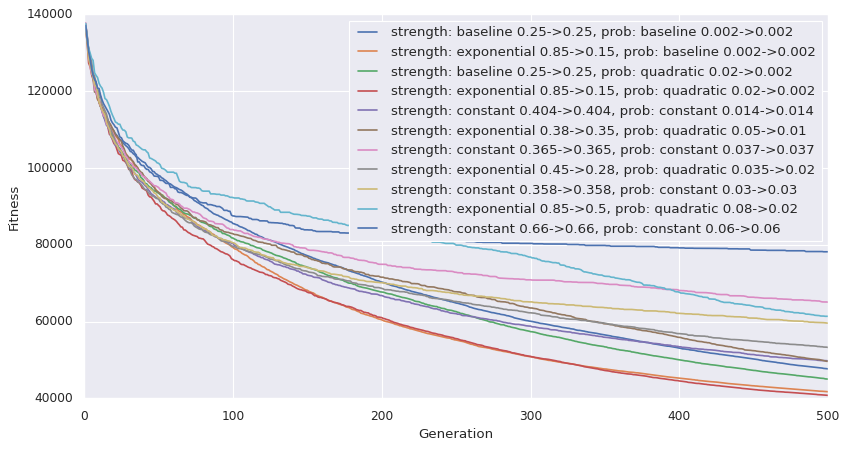

In [97]:
fig, ax = plt.subplots(figsize=(12,6))

for (schedule_s, init_s, final_s, schedule_p, init_p, final_p) in configs:

    sub = df[
        (df["mutation-strength-schedule"] == schedule_s) &
        (df["initial-mutation-strength"] == init_s) &
        (df["final-mutation-strength"] == final_s) &
        (df["mutation-prob-schedule"] == schedule_p) &
        (df["initial-mutation-prob"] == init_p) &
        (df["final-mutation-prob"] == final_p)
    ]

    mean_curve = sub.groupby("num-generations")["best-fitness"].mean()

    ax.plot(mean_curve.index, mean_curve.values,
            label=f"strength: {schedule_s} {round(init_s,3)}->{round(final_s,3)}, prob: {schedule_p} {round(init_p,3)}->{round(final_p,3)}")

ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")
ax.legend(fontsize=12)
plt.show()

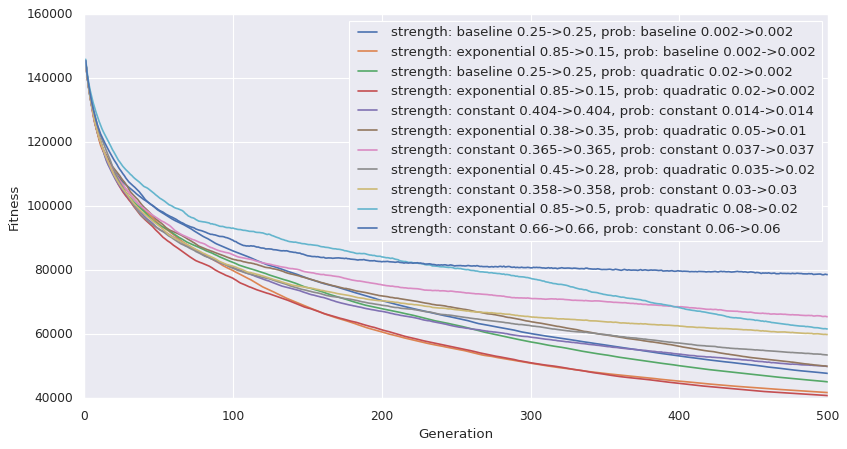

In [98]:
fig, ax = plt.subplots(figsize=(12,6))

for (schedule_s, init_s, final_s, schedule_p, init_p, final_p) in configs:

    sub = df[
        (df["mutation-strength-schedule"] == schedule_s) &
        (df["initial-mutation-strength"] == init_s) &
        (df["final-mutation-strength"] == final_s) &
        (df["mutation-prob-schedule"] == schedule_p) &
        (df["initial-mutation-prob"] == init_p) &
        (df["final-mutation-prob"] == final_p)
    ]

    mean_curve = sub.groupby("num-generations")["avg-fitness"].mean()

    ax.plot(mean_curve.index, mean_curve.values,
            label=f"strength: {schedule_s} {round(init_s,3)}->{round(final_s,3)}, prob: {schedule_p} {round(init_p,3)}->{round(final_p,3)}")

ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")
ax.legend(fontsize=12)
plt.show()

In [99]:
df["config"] = (
    df["mutation-strength-schedule"].astype(str) + "_" +
    df["initial-mutation-strength"].round(3).astype(str) + "_" +
    df["final-mutation-strength"].round(3).astype(str) + "_" +
    df["mutation-prob-schedule"].astype(str) + "_" +
    df["initial-mutation-prob"].fillna(-1).round(4).astype(str) + "_" +
    df["final-mutation-prob"].fillna(-1).round(4).astype(str)
)
df["config"].unique()

array(['baseline_0.25_0.25_baseline_0.002_0.002',
       'exponential_0.85_0.15_baseline_0.002_0.002',
       'baseline_0.25_0.25_quadratic_0.02_0.002',
       'exponential_0.85_0.15_quadratic_0.02_0.002',
       'constant_0.404_0.404_constant_0.014_0.014',
       'exponential_0.38_0.35_quadratic_0.05_0.01',
       'constant_0.365_0.365_constant_0.0367_0.0367',
       'exponential_0.45_0.28_quadratic_0.035_0.02',
       'constant_0.358_0.358_constant_0.03_0.03',
       'exponential_0.85_0.5_quadratic_0.08_0.02',
       'constant_0.66_0.66_constant_0.06_0.06'], dtype=object)

In [114]:
palette = {
    'baseline_0.25_0.25_baseline_0.002_0.002': "black",
    'exponential_0.85_0.15_baseline_0.002_0.002': "tab:gray",
    'baseline_0.25_0.25_quadratic_0.02_0.002': "tab:grey",
    'exponential_0.85_0.15_quadratic_0.02_0.002': "tab:green",
    'constant_0.404_0.404_constant_0.014_0.014': "tab:green",
    'exponential_0.38_0.35_quadratic_0.05_0.01': "tab:blue",
    'constant_0.365_0.365_constant_0.0367_0.0367': "tab:blue",
    'exponential_0.45_0.28_quadratic_0.035_0.02': "tab:red",
    'constant_0.358_0.358_constant_0.03_0.03': "tab:red",
    'exponential_0.85_0.5_quadratic_0.08_0.02': "tab:orange",
    'constant_0.66_0.66_constant_0.06_0.06': "tab:orange"
}

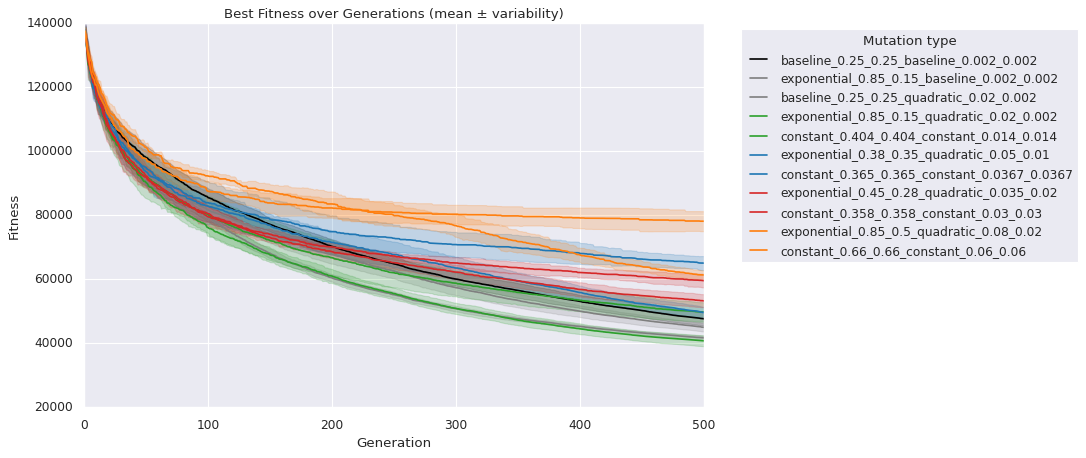

In [113]:
sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(10,6))

sns.lineplot(
    data=df,
    x="num-generations",
    y="best-fitness",
    hue="config",
    palette=palette,
    errorbar="sd",   # or "ci"
    ax=ax
)

ax.set_title("Best Fitness over Generations (mean ± variability)")
ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")
ax.legend(title="Mutation type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

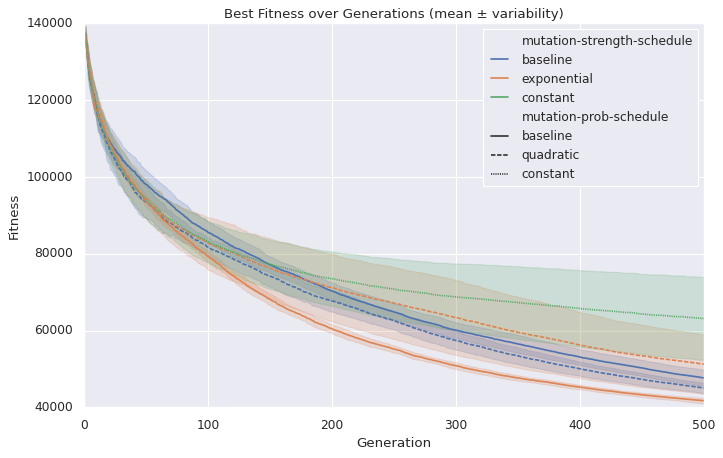

In [87]:
sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(10,6))

sns.lineplot(
    data=df,
    x="num-generations",
    y="best-fitness",
    hue="mutation-strength-schedule",
    style="mutation-prob-schedule",
    errorbar="sd"
)

ax.set_title("Best Fitness over Generations (mean ± variability)")
ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")

plt.show()

In [35]:
filtered1 = df[
    (
        (df["mutation-strength-schedule"] == "baseline") &
        (df["mutation-prob-schedule"] == "baseline")
    )
    |
    (
        (df["mutation-strength-schedule"] == "exponential") &
        (df["mutation-prob-schedule"] == "quadratic")
    )
]

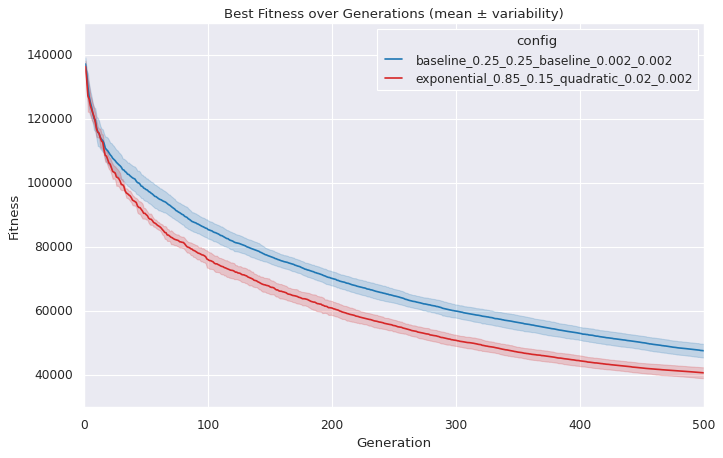

In [52]:
sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(10,6))

sns.lineplot(
    data=filtered1,
    x="num-generations",
    y="best-fitness",
    hue="config",
    palette=palette,
    errorbar="sd",   # or "ci"
    ax=ax
)

ax.set_title("Best Fitness over Generations (mean ± variability)")
ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")

ax.set_ylim(30000, 150000)

plt.show()

In [74]:
filtered2 = df[
    (
        (df["mutation-strength-schedule"] == "baseline") &
        (df["mutation-prob-schedule"] == "baseline")
    )
    |
    (
        (df["mutation-strength-schedule"] == "constant") &
        (df["mutation-prob-schedule"] == "constant")
    )
    |
    (
        (df["mutation-strength-schedule"] == "exponential") &
        (df["mutation-prob-schedule"] == "quadratic")
    )
]

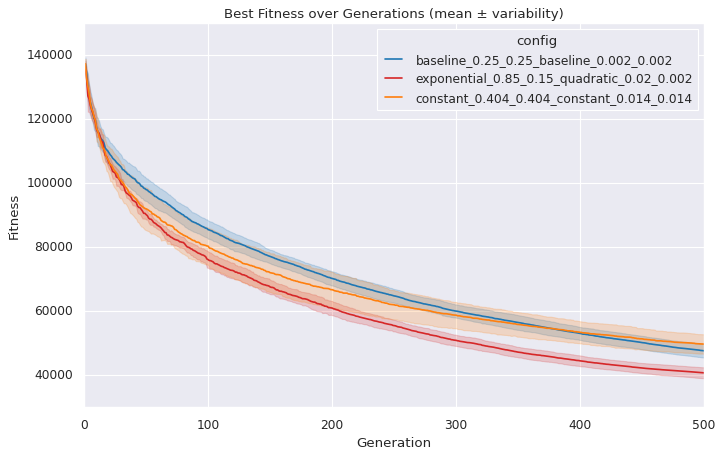

In [75]:
sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(10,6))

sns.lineplot(
    data=filtered2,
    x="num-generations",
    y="best-fitness",
    hue="config",
    palette=palette,
    errorbar="sd",   # or "ci"
    ax=ax
)

ax.set_title("Best Fitness over Generations (mean ± variability)")
ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")

ax.set_ylim(30000, 150000)

plt.show()

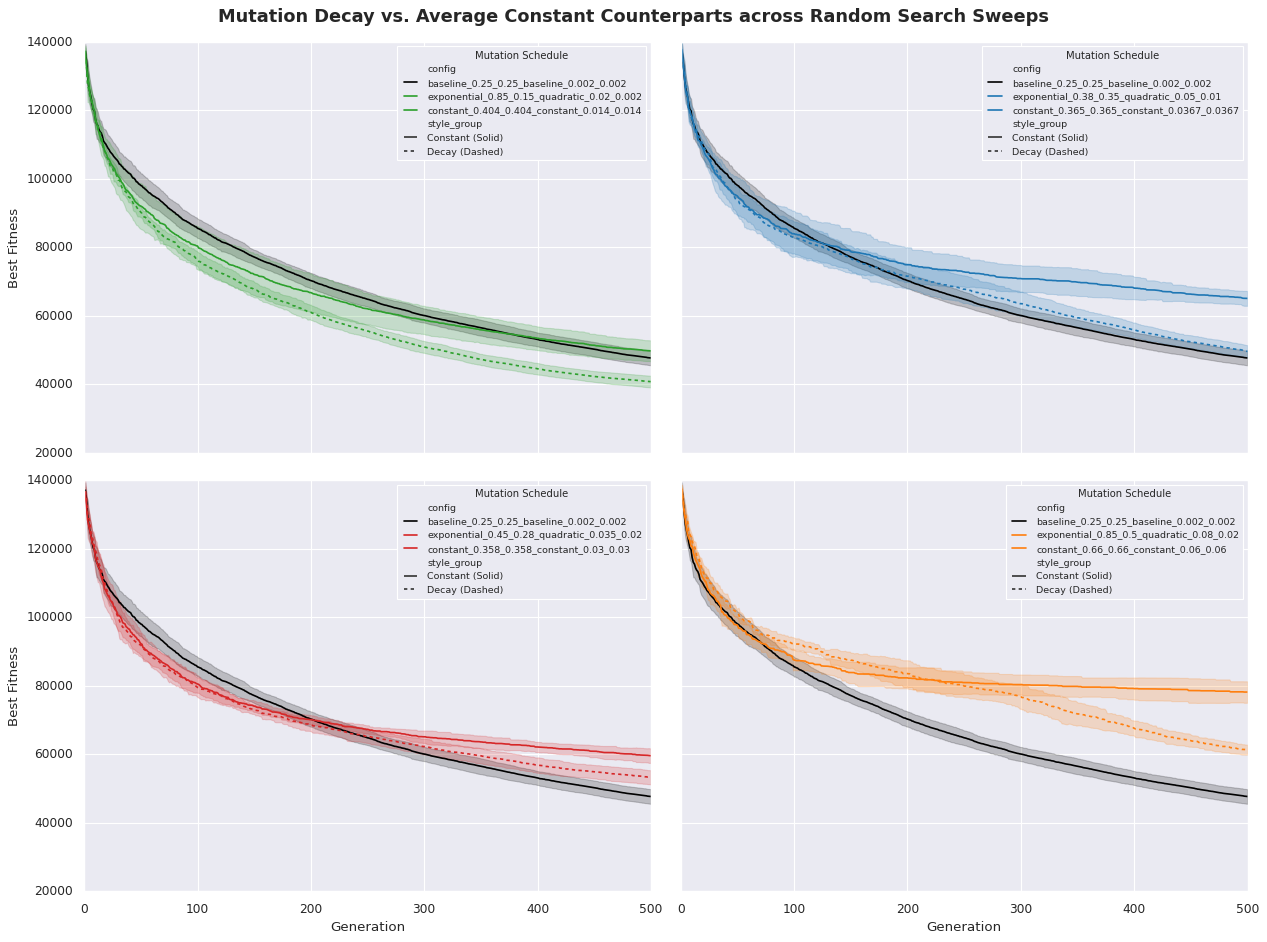

In [118]:
### plot by gemini

# 1. Define the line style group based on whether decay schedules exist in the config
def determine_style(config_str):
    if "exponential" in config_str or "quadratic" in config_str:
        return "Decay (Dashed)"
    return "Constant (Solid)"

df["style_group"] = df["config"].apply(determine_style)

# 2. Map your exact palette
palette = {
    'baseline_0.25_0.25_baseline_0.002_0.002': "black",
    'exponential_0.85_0.15_baseline_0.002_0.002': "tab:gray",
    'baseline_0.25_0.25_quadratic_0.02_0.002': "tab:grey",
    'exponential_0.85_0.15_quadratic_0.02_0.002': "tab:green",
    'constant_0.404_0.404_constant_0.014_0.014': "tab:green",
    'exponential_0.38_0.35_quadratic_0.05_0.01': "tab:blue",
    'constant_0.365_0.365_constant_0.0367_0.0367': "tab:blue",
    'exponential_0.45_0.28_quadratic_0.035_0.02': "tab:red",
    'constant_0.358_0.358_constant_0.03_0.03': "tab:red",
    'exponential_0.85_0.5_quadratic_0.08_0.02': "tab:orange",
    'constant_0.66_0.66_constant_0.06_0.06': "tab:orange"
}

# 3. Define the subplots configuration matrix
# We share the black baseline across all subplots for a consistent benchmark comparison
baseline = 'baseline_0.25_0.25_baseline_0.002_0.002'

subplots_def = [
    {
        "configs": [
            'exponential_0.85_0.15_quadratic_0.02_0.002', 
            'constant_0.404_0.404_constant_0.014_0.014',
            baseline
        ]
    },
    {
        "configs": [
            'exponential_0.38_0.35_quadratic_0.05_0.01', 
            'constant_0.365_0.365_constant_0.0367_0.0367',
            baseline
        ]
    },
    {
        "configs": [
            'exponential_0.45_0.28_quadratic_0.035_0.02', 
            'constant_0.358_0.358_constant_0.03_0.03',
            baseline
        ]
    },
    {
        "configs": [
            'exponential_0.85_0.5_quadratic_0.08_0.02', 
            'constant_0.66_0.66_constant_0.06_0.06',
            baseline
        ]
    }
]

# 4. Initialize the 2x2 grid
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Map the custom style string to explicit line dashes
# (1, 0) produces a completely solid line; (3, 3) produces a standard dashed line
style_dashes = {
    "Constant (Solid)": (1, 0),
    "Decay (Dashed)": (3, 3)
}

for i, sub in enumerate(subplots_def):
    ax = axes[i]
    
    # Filter the dataframe to only contain the configs intended for this subplot
    sub_df = df[df["config"].isin(sub["configs"])]
    
    sns.lineplot(
        data=sub_df,
        x="num-generations",
        y="best-fitness",
        hue="config",
        palette=palette,
        style="style_group",
        dashes=style_dashes,
        errorbar="sd",
        ax=ax
    )
    
    # Visual Adjustments
    ax.set_xlabel("Generation" if i >= 2 else "")
    ax.set_ylabel("Best Fitness" if i % 2 == 0 else "")
    
    # Clean up and position the legends inside/outside cleanly
    ax.legend(title="Mutation Schedule", loc="upper right", fontsize=8.5, title_fontsize=9)

# Global adjustments
fig.suptitle("Mutation Decay vs. Average Constant Counterparts across Random Search Sweeps", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

## Displaying the best instances over time

In [24]:
def show_progress_over_time(settings, selection=None, grid=(5,4)):
    seed, mutation_strength_schedule, initial_mutation_strength, final_mutation_strength, mutation_prob_schedule, initial_mutation_prob, final_mutation_prob = settings
    fig = plt.figure(figsize=(20., 20.))
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=grid,
                     axes_pad=0.1,  # pad between axes
                     )

    if selection is None:
        selection = range(50, 500 + 50, 50)
    
    img_arr = [Image.open((f"./img/van_gogh_intermediate_{seed}_{mutation_strength_schedule}_{initial_mutation_strength}_{final_mutation_strength}_{mutation_prob_schedule}_{initial_mutation_prob}_{final_mutation_prob}_{i:05d}.png")) for i in selection]
    for ax, im in zip(grid, img_arr):
        ax.imshow(im)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

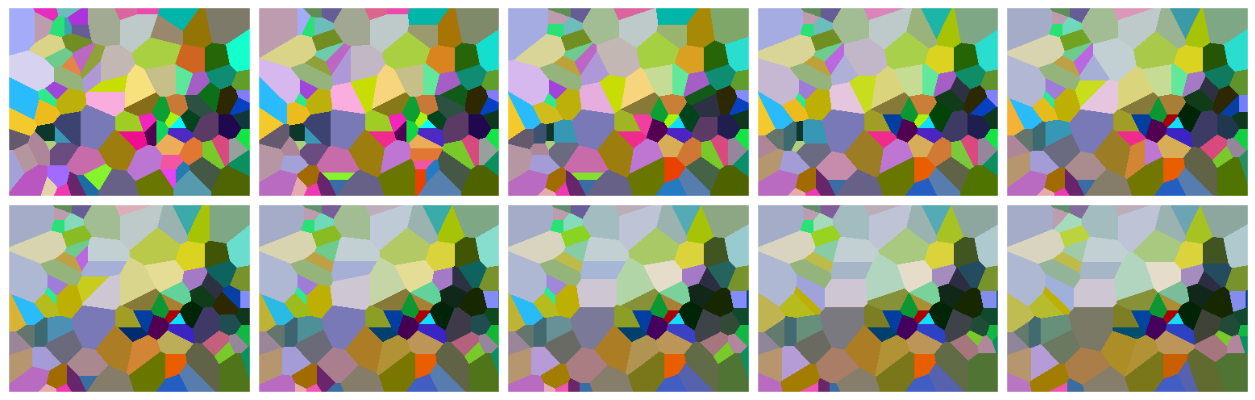

In [63]:
show_progress_over_time((0, "baseline", 0.25, 0.25, "baseline", prob_baseline, prob_baseline), grid=(2,5))

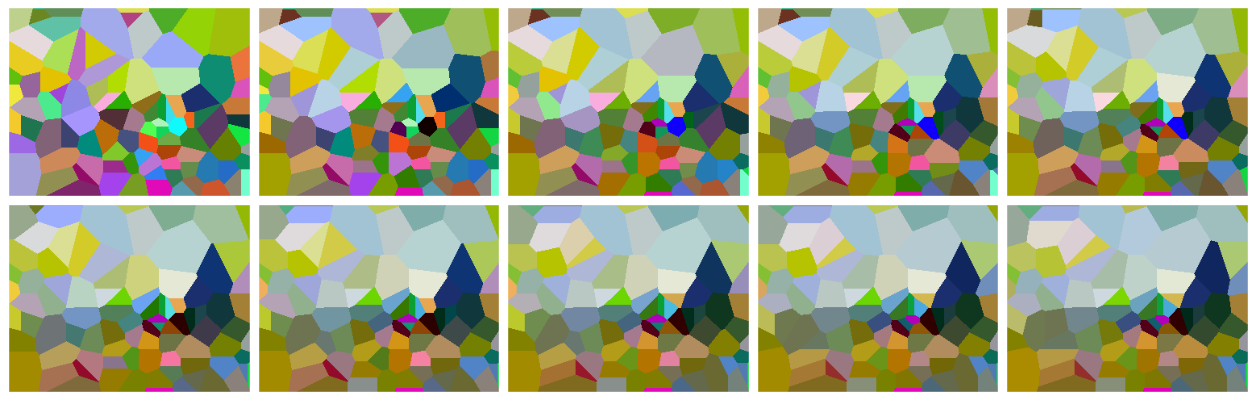

In [58]:
show_progress_over_time((0, "exponential", 0.85, 0.15, "baseline", prob_baseline, prob_baseline), grid=(2,5))

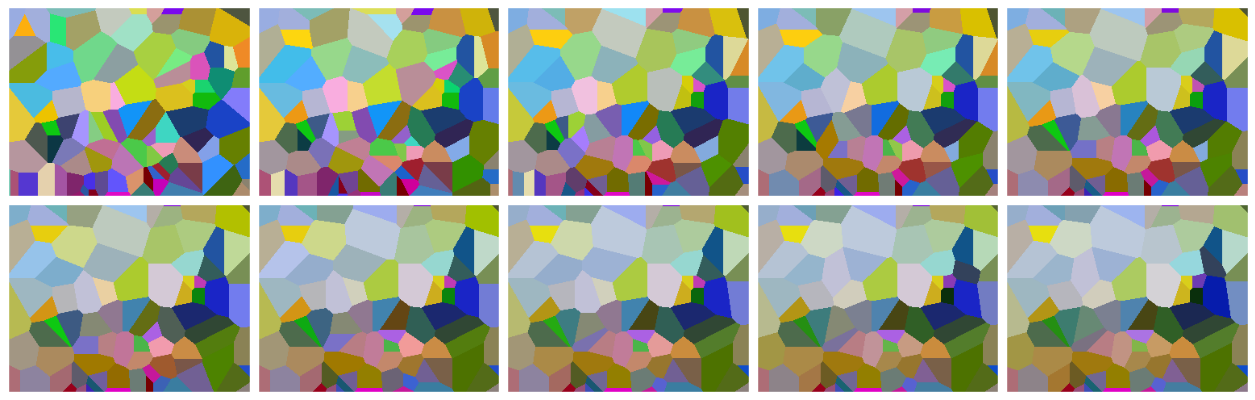

In [57]:
show_progress_over_time((0, "baseline", 0.25, 0.25, "quadratic", 0.02, 0.002), grid=(2,5))

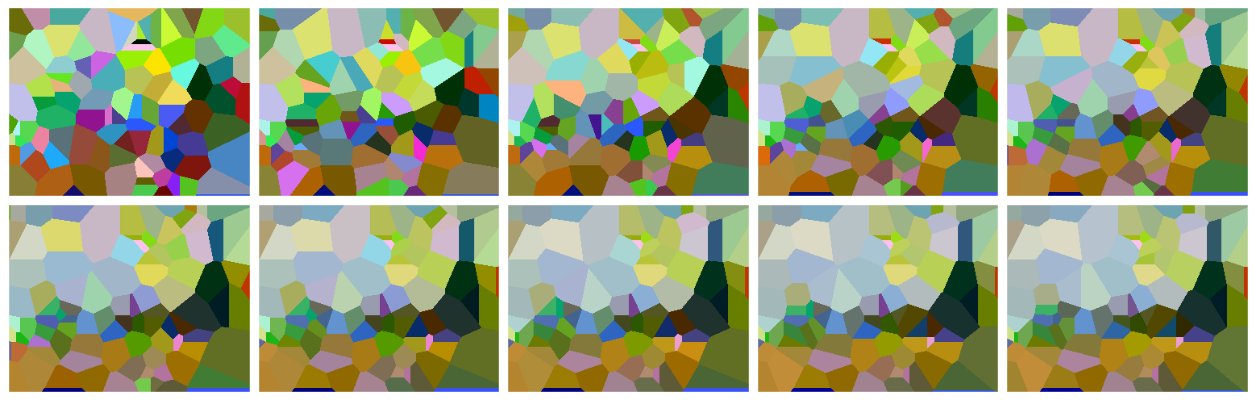

In [71]:
show_progress_over_time((3, "exponential", 0.85, 0.15, "quadratic", 0.02, 0.002), grid=(2,5))

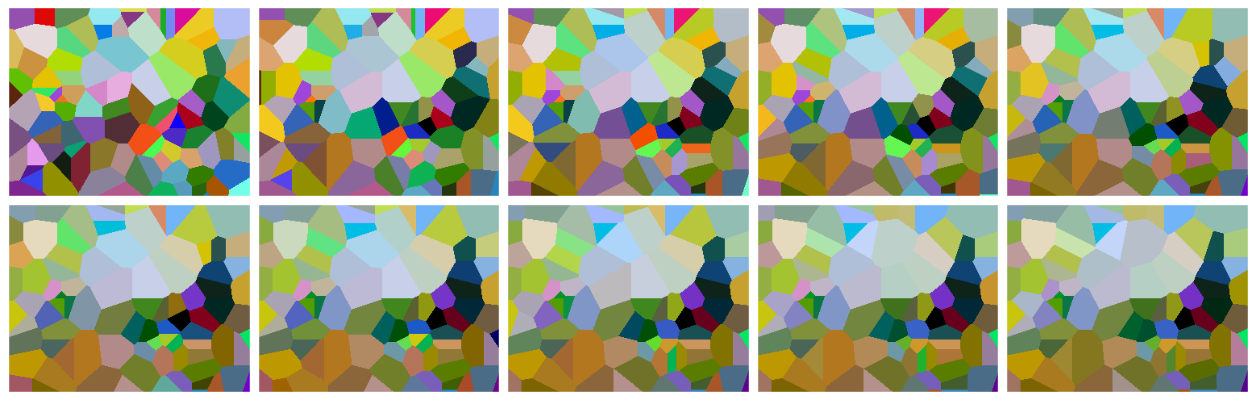

In [33]:
show_progress_over_time((0, "constant", sum(strength_values) / generation_budget, sum(strength_values) / generation_budget, "constant", sum(prob_values) / generation_budget, sum(prob_values) / generation_budget), grid=(2,5))